In [1]:
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
from shapely.geometry import box
from shapely import from_wkt
import rasterio
from rasterio.warp import transform_bounds
from rasterio.crs import CRS
from rasterio import default_gtiff_profile
from rasterio.transform import from_origin
import numpy as np
import matplotlib.pyplot as plt

from dist_s1_enumerator.mgrs_burst_data import get_mgrs_table, get_mgrs_tiles_overlapping_geometry, get_mgrs_tile_table_by_ids

/Users/cmarshak/miniforge3/envs/distmetrics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Interactive Portion

In [2]:
df_mgrs = get_mgrs_table()

In [3]:
df_mgrs.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
1,01FBF,32701,"MULTIPOLYGON(((199980 4600000,199980 4490200,3...","MULTIPOLYGON (((-179.58653 -48.72398, -179.638..."
2,01GBH,32701,"MULTIPOLYGON(((199980 4800040,199980 4690240,3...","MULTIPOLYGON (((-179.49865 -46.9259, -179.5458..."
3,01GDM,32701,"MULTIPOLYGON(((399960 5200000,399960 5090200,5...","POLYGON ((-178.23431 -43.34619, -178.25485 -44..."
4,01GEL,32701,"MULTIPOLYGON(((499980 5100040,499980 4990240,6...","POLYGON ((-177.00025 -44.25288, -177.00025 -45..."


In [4]:
df_mgrs.utm_wkt[0]

'MULTIPOLYGON(((199980 4500040,199980 4390240,309780 4390240,309780 4500040,199980 4500040)))'

In [5]:
with rasterio.open('disturbance_track64_2025-01-09.tif') as ds:
    X_src = ds.read(1)
    p_src = ds.profile
    bounds_utm = ds.bounds
    crs_utm = ds.crs

In [6]:
bounds_4326 = transform_bounds(crs_utm, CRS.from_epsg(4326), *bounds_utm)
bounds_4326

(-119.15225995009473, 32.95845232263299, -116.80664731745985, 35.2498388740419)

In [7]:
tif_geo_4326 = box(*bounds_4326)

In [8]:
df_mgrs_overlapping = get_mgrs_tiles_overlapping_geometry(tif_geo_4326)
df_mgrs_overlapping.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,11SKS,32611,"MULTIPOLYGON(((199980 3700020,199980 3590220,3...","POLYGON ((-120.22553 33.39762, -120.18984 32.4..."
1,11SKT,32611,"MULTIPOLYGON(((199980 3800040,199980 3690240,3...","POLYGON ((-120.2596 34.29827, -120.22228 33.30..."
2,11SKU,32611,"MULTIPOLYGON(((199980 3900000,199980 3790200,3...","POLYGON ((-120.29518 35.19821, -120.25618 34.2..."
3,11SKV,32611,"MULTIPOLYGON(((199980 4000020,199980 3890220,3...","POLYGON ((-120.33241 36.09852, -120.29163 35.1..."
4,11SLS,32611,"MULTIPOLYGON(((300000 3700020,300000 3590220,4...","POLYGON ((-119.15104 33.42092, -119.12721 32.4..."


In [9]:
df_mgrs_overlapping.explore()

# Getting an MGRS Profile

In [10]:
TARGET_TILE = '11SLT'

In [16]:
def get_mgrs_bounds(mgrs_tile_id: str) -> tuple[float]:
    df_mgrs = get_mgrs_tile_table_by_ids([mgrs_tile_id])
    utm_wkt = df_mgrs['utm_wkt'].tolist()[0]
    utm_geo = from_wkt(utm_wkt)
    return utm_geo.bounds


def get_mgrs_utm_epsg(mgrs_tile_id: str) -> tuple[float]:
    df_mgrs = get_mgrs_tile_table_by_ids([mgrs_tile_id])
    utm_epsg = df_mgrs['utm_epsg'].tolist()[0]
    utm_crs = CRS.from_epsg(utm_epsg)
    return utm_crs


def get_mgrs_profile(mgrs_tile_id: str, count: int = 1, dtype: np.dtype = np.float32, nodata: float = np.nan) -> dict:
    profile = default_gtiff_profile.copy()

    xmin, ymin, xmax, ymax = get_mgrs_bounds(mgrs_tile_id)
    transform = from_origin(xmin, ymax, 30, 30)
    utm_crs = get_mgrs_utm_epsg(mgrs_tile_id)

    profile['transform'] = transform
    profile['crs'] = utm_crs
    profile['count'] = count
    profile['dtype'] = dtype
    profile['nodata'] = nodata
    profile['width'] = 3660
    profile['height'] = 3660

    dims = [(xmax - xmin) / 30.0, (ymax - ymin) / 30.0]
    if all([3660.0 != diff for diff in dims]):
        dim_str = ', '.join(list(map(str, dims)))
        raise ValueError(f'The expected dimensions of 3660 disagree with the mgrs table: {dim_str}')
    return profile

In [17]:
xmin, ymin, xmax, ymax = get_mgrs_bounds(TARGET_TILE)

In [18]:
(xmax - xmin) / 30

3660.0

In [19]:
(ymax - ymin) / 30

3660.0

In [20]:
mgrs_profile = get_mgrs_profile(TARGET_TILE)
mgrs_profile

{'driver': 'GTiff', 'interleave': 'band', 'tiled': True, 'blockxsize': 256, 'blockysize': 256, 'compress': 'lzw', 'nodata': nan, 'dtype': <class 'numpy.float32'>, 'transform': Affine(30.0, 0.0, 300000.0,
       0.0, -30.0, 3800040.0), 'crs': CRS.from_epsg(32611), 'count': 1, 'width': 3660, 'height': 3660}

In [21]:
X_dist_mgrs, p_dist_mgrs = reproject_arr_to_match_profile(X_src, p_src, mgrs_profile)

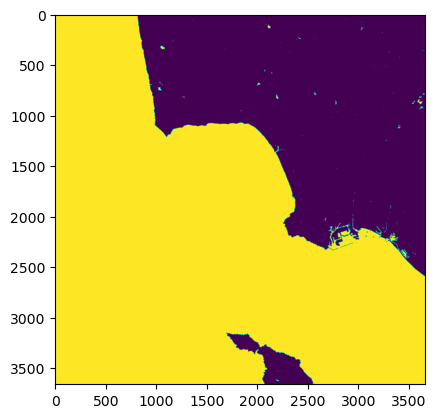

In [22]:
plt.imshow(X_dist_mgrs[0, ...])

In [26]:
with rasterio.open('OPERA_L3_DIST-ALERT-HLS_T11SLT_20250127T183539Z_20250129T051243Z_S2B_30_v1_VEG-DIST-STATUS.tif') as ds:
    p_opera = ds.profile

In [27]:
p_opera

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 255.0, 'width': 3660, 'height': 3660, 'count': 1, 'crs': CRS.from_epsg(32611), 'transform': Affine(30.0, 0.0, 300000.0,
       0.0, -30.0, 3800040.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

In [28]:
p_opera['transform'] == p_dist_mgrs['transform']

True

In [29]:
p_opera['crs'] == p_dist_mgrs['crs']

True